# EDA — Santo Domingo Precipitation Patterns

Exploring 10 years (2015-2024) of daily weather data pulled from the Open-Meteo Historical Weather API, with a focus on precipitation patterns to inform the rain/no-rain classification threshold for the logistic regression model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/santo_domingo_historical.csv", parse_dates=["date"])
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,windspeed_10m_max,precipitation_sum,month,year
0,2015-01-01,28.4,20.9,24.3,77,1013.4,11.5,0.0,1,2015
1,2015-01-02,28.8,21.6,24.6,76,1014.8,14.9,0.6,1,2015
2,2015-01-03,28.5,21.2,24.2,76,1015.1,19.8,1.2,1,2015
3,2015-01-04,29.3,21.3,24.6,73,1015.4,18.0,0.0,1,2015
4,2015-01-05,29.3,21.2,24.5,71,1015.9,15.5,0.0,1,2015


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       3653 non-null   datetime64[us]
 1   temperature_2m_max         3653 non-null   float64       
 2   temperature_2m_min         3653 non-null   float64       
 3   temperature_2m_mean        3653 non-null   float64       
 4   relative_humidity_2m_mean  3653 non-null   int64         
 5   surface_pressure_mean      3653 non-null   float64       
 6   windspeed_10m_max          3653 non-null   float64       
 7   precipitation_sum          3653 non-null   float64       
 8   month                      3653 non-null   int32         
 9   year                       3653 non-null   int32         
dtypes: datetime64[us](1), float64(6), int32(2), int64(1)
memory usage: 257.0 KB


,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,windspeed_10m_max,precipitation_sum,month,year
count,3653,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,2020-01-01 00:00:00,29.388612,22.418560,25.460827,80.117985,1009.676102,15.143088,3.298056,6.522310,2019.500411
min,2015-01-01 00:00:00,24.400000,16.700000,21.400000,57.000000,999.000000,6.300000,0.000000,1.000000,2015.000000
25%,2017-07-02 00:00:00,28.300000,21.300000,24.400000,77.000000,1008.400000,12.700000,0.400000,4.000000,2017.000000
50%,2020-01-01 00:00:00,29.400000,22.600000,25.400000,81.000000,1009.900000,14.800000,1.400000,7.000000,2020.000000
75%,2022-07-02 00:00:00,30.400000,23.600000,26.500000,84.000000,1011.200000,17.100000,3.400000,10.000000,2022.000000
max,2024-12-31 00:00:00,35.300000,26.800000,29.100000,95.000000,1016.100000,60.000000,137.800000,12.000000,2024.000000
std,NaN,1.479075,1.484246,1.329506,5.304737,2.176158,3.630880,6.500199,3.449345,2.873056


## Precipitation distribution

`precipitation_sum` is heavily right-skewed (many dry days, occasional heavy-rain days), which is typical for a tropical climate. A log1p view makes the non-zero tail easier to read.

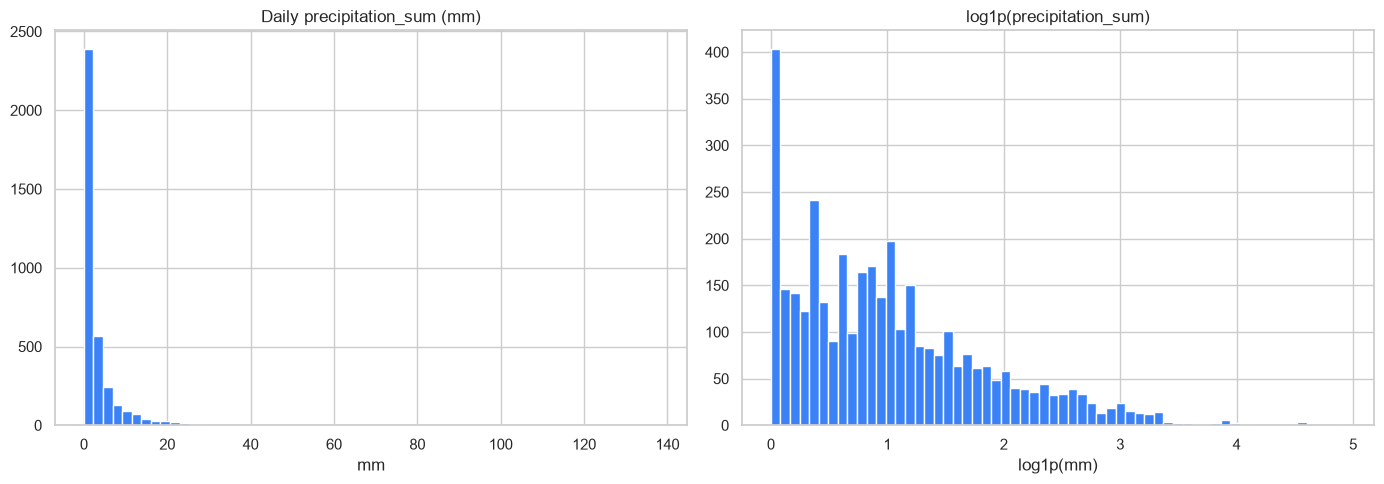

Zero-precipitation days: 403 (11.0%)


count    3653.000000
mean        3.298056
std         6.500199
min         0.000000
25%         0.400000
50%         1.400000
75%         3.400000
max       137.800000
Name: precipitation_sum, dtype: float64

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["precipitation_sum"], bins=60, color="#3b82f6")
axes[0].set_title("Daily precipitation_sum (mm)")
axes[0].set_xlabel("mm")

axes[1].hist(np.log1p(df["precipitation_sum"]), bins=60, color="#3b82f6")
axes[1].set_title("log1p(precipitation_sum)")
axes[1].set_xlabel("log1p(mm)")

plt.tight_layout()
plt.show()

print("Zero-precipitation days:", (df["precipitation_sum"] == 0).sum(), f"({(df['precipitation_sum'] == 0).mean():.1%})")
df["precipitation_sum"].describe()

## Choosing a rain / no-rain threshold

We compare a few common thresholds for "measurable rain" (the WMO standard is >=1.0 mm for a wet day) and see how each affects class balance.

In [4]:
thresholds = [0.1, 0.5, 1.0, 2.5]
for t in thresholds:
    rain_share = (df["precipitation_sum"] >= t).mean()
    print(f"threshold >= {t:>4} mm  ->  rain days: {rain_share:.1%}  |  no-rain: {1 - rain_share:.1%}")

threshold >=  0.1 mm  ->  rain days: 89.0%  |  no-rain: 11.0%
threshold >=  0.5 mm  ->  rain days: 74.2%  |  no-rain: 25.8%
threshold >=  1.0 mm  ->  rain days: 60.0%  |  no-rain: 40.0%
threshold >=  2.5 mm  ->  rain days: 32.0%  |  no-rain: 68.0%


## Seasonality

Santo Domingo has a tropical climate with a clear wet season (roughly May-November, peaking around hurricane season) and a drier season (December-April). We check monthly rain frequency and average precipitation to confirm this shows up in the data.

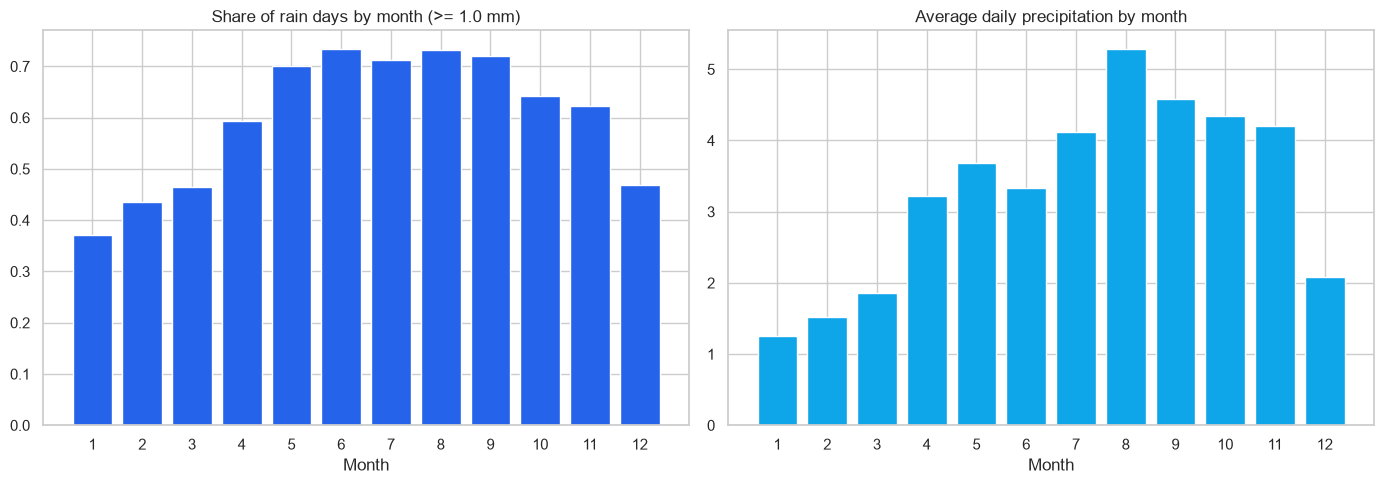

,month,rain_frequency,avg_precip_mm
0,1,0.370968,1.254516
1,2,0.434629,1.522615
2,3,0.464516,1.858065
3,4,0.593333,3.219000
4,5,0.700000,3.686129
5,6,0.733333,3.334333
6,7,0.712903,4.122903
7,8,0.732258,5.281290
8,9,0.720000,4.580000
9,10,0.641935,4.342258


In [5]:
RAIN_THRESHOLD = 1.0  # mm, WMO wet-day definition
df["is_rain"] = (df["precipitation_sum"] >= RAIN_THRESHOLD).astype(int)

monthly = df.groupby("month").agg(
    rain_frequency=("is_rain", "mean"),
    avg_precip_mm=("precipitation_sum", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(monthly["month"], monthly["rain_frequency"], color="#2563eb")
axes[0].set_title(f"Share of rain days by month (>= {RAIN_THRESHOLD} mm)")
axes[0].set_xlabel("Month")
axes[0].set_xticks(range(1, 13))

axes[1].bar(monthly["month"], monthly["avg_precip_mm"], color="#0ea5e9")
axes[1].set_title("Average daily precipitation by month")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()
monthly

## Relationship between predictors and rain

Humidity and pressure are the classic rain predictors. We check correlation with `is_rain` and compare feature distributions on rain vs. no-rain days.

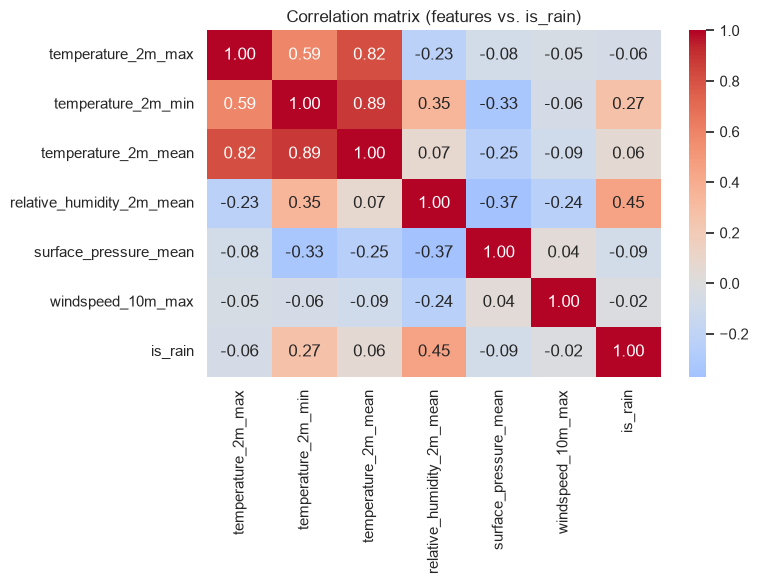

In [6]:
feature_cols = [
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "windspeed_10m_max",
]

corr = df[feature_cols + ["is_rain"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (features vs. is_rain)")
plt.tight_layout()
plt.show()

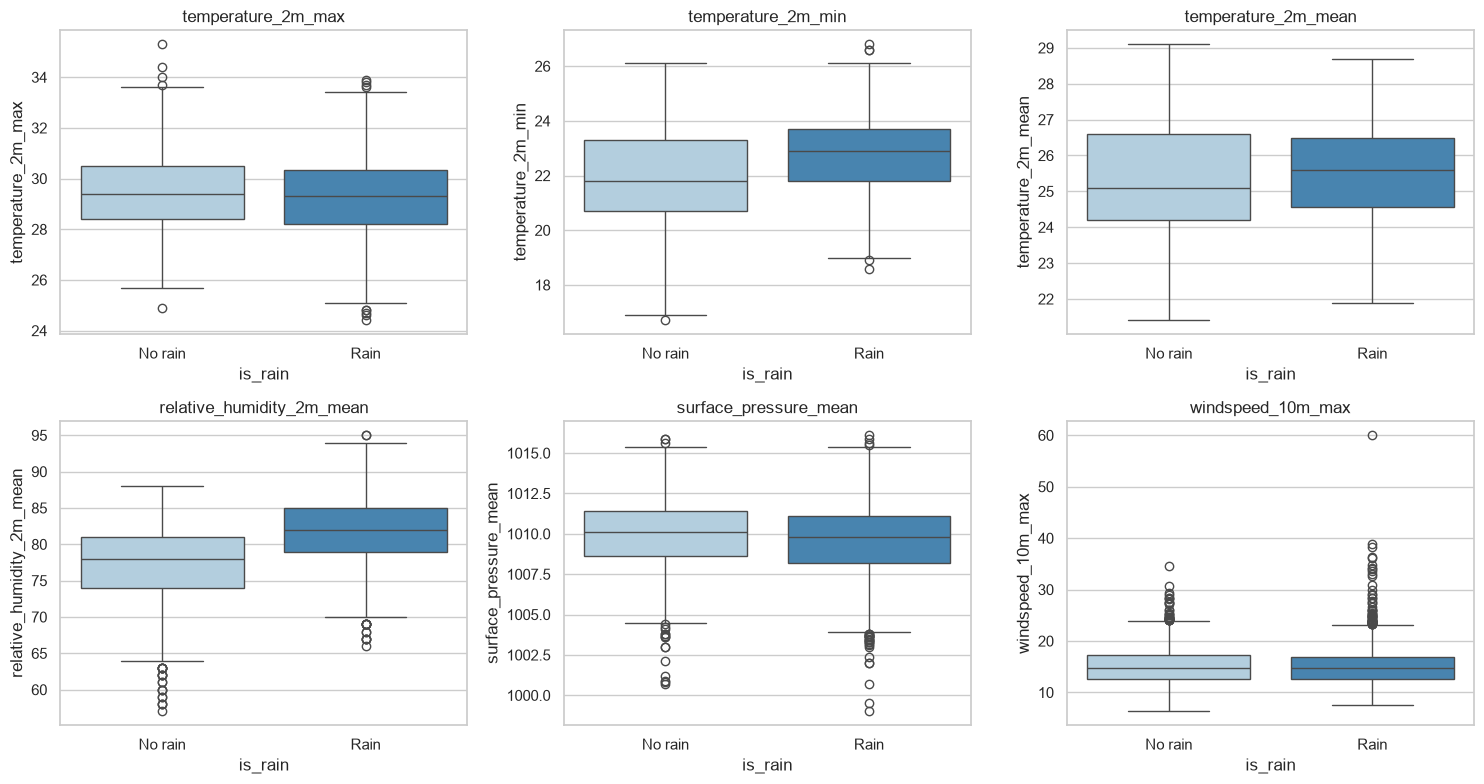

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=df, x="is_rain", y=col, ax=ax, hue="is_rain", palette="Blues", legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No rain", "Rain"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Summary

- 10 years of daily data (2015-2024), 3,653 rows, no missing values.
- Only 11.0% of days are fully dry (0 mm); precipitation is heavily right-skewed above that, consistent with a tropical climate.
- The WMO wet-day threshold (`precipitation_sum >= 1.0 mm`) gives a **60% rain / 40% no-rain** split — a well-balanced target for logistic regression, and standards-backed rather than an arbitrary cutoff.
- Rain frequency and average precipitation both show clear seasonality: higher in the wet season (~May-Nov), lower in the dry season (~Dec-Apr) — `month` (or a cyclical encoding of it) is worth engineering as a feature.
- Humidity correlates positively with rain and pressure negatively, matching meteorological expectations; both are reasonable logistic regression features alongside temperature and wind.

Next step: feature engineering + train/test split + logistic regression baseline (`notebooks/02_modeling.ipynb`).